<a href="https://colab.research.google.com/github/Rushaida0077/Phishing-Website-Detection/blob/main/Phishing_Website_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install & imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install tldextract joblib --quiet


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from imblearn.over_sampling import SMOTE
import joblib

sns.set(style='whitegrid', rc={'figure.figsize':(8,5)})


# Load the dataset

In [ ]:
phish_data = pd.read_csv(
    '/content/drive/MyDrive/Phishing_Detection_Project/All.csv',
    low_memory=False
)

phish_data.head()


,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


#Data Cleaning & Preprocessing

**Dataset Information**

In [ ]:
print("Shape:", phish_data.shape)
print("\nDataset Info:")
print(phish_data.info())

print("\nMissing Values:")
print(phish_data.isnull().sum())

print("\n\nDuplicate rows:")
print(phish_data.duplicated().sum())

phish_data.replace([np.inf, -np.inf], np.nan, inplace=True)


Shape: (36707, 80)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36707 entries, 0 to 36706
Data columns (total 80 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      36707 non-null  int64  
 1   domain_token_count               36707 non-null  int64  
 2   path_token_count                 36707 non-null  int64  
 3   avgdomaintokenlen                36707 non-null  float64
 4   longdomaintokenlen               36707 non-null  int64  
 5   avgpathtokenlen                  36427 non-null  float64
 6   tld                              36707 non-null  int64  
 7   charcompvowels                   36707 non-null  int64  
 8   charcompace                      36707 non-null  int64  
 9   ldl_url                          36707 non-null  int64  
 10  ldl_domain                       36707 non-null  int64  
 11  ldl_path                         36707 non-nul

**Dataset Summary Statistics**

In [ ]:
phish_data.describe()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_Directoryname,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath
count,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36427.000000,36707.000000,36707.000000,36707.000000,36707.000000,...,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,28239.000000,36471.000000,36667.000000,36701.000000
mean,21.908110,2.857439,8.954668,5.401719,9.746016,4.556261,2.857439,14.976517,10.216117,3.363909,...,1.727545,3.600049,2.685237,1.903261,0.722350,0.842443,0.677459,0.715834,0.508212,-0.208900
std,94.280669,0.906562,4.278406,1.986858,4.856580,2.839388,0.906562,13.351315,10.845807,13.447289,...,2.719231,4.783213,4.557171,4.512421,0.048820,0.066251,0.450683,0.411712,0.519695,0.891581
min,0.000000,2.000000,0.000000,1.500000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.419560,0.561913,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,2.000000,6.000000,4.000000,6.000000,3.000000,2.000000,7.000000,5.000000,0.000000,...,-1.000000,0.000000,0.000000,-1.000000,0.691929,0.795234,0.731621,0.719904,0.000000,-1.000000
50%,0.000000,3.000000,8.000000,5.000000,9.000000,4.100000,3.000000,13.000000,8.000000,0.000000,...,1.000000,1.000000,0.000000,-1.000000,0.723003,0.835752,0.790535,0.785150,0.729292,-1.000000
75%,19.000000,3.000000,11.000000,6.500000,12.000000,5.000000,3.000000,19.000000,12.000000,1.000000,...,3.000000,6.000000,4.000000,3.000000,0.754305,0.884735,0.851410,0.884662,0.910005,0.758695
max,1385.000000,19.000000,68.000000,29.500000,63.000000,105.000000,19.000000,193.000000,142.000000,207.000000,...,24.000000,40.000000,39.000000,40.000000,0.895403,1.000000,0.962479,1.000000,1.000000,1.000000


**Duplicate Handling**

In [ ]:
phish_data.drop_duplicates(inplace=True)

**Handle Missing & Infinite Values**
`avgpathtokenlen`, `NumberRate_FileName`, `Entropy_Filename` have missing values. and Replace inf/-inf with NaN

In [ ]:
# Fill numeric missing values with column median
phish_data.replace([np.inf, -np.inf], np.nan, inplace=True)
numeric_cols = phish_data.select_dtypes(include=[np.number]).columns
phish_data[numeric_cols] = phish_data[numeric_cols].fillna(phish_data[numeric_cols].median())



**Encoding the target column**

In [ ]:
label_encoder = LabelEncoder()
phish_data["URL_Type_obf_Type"] = label_encoder.fit_transform(
    phish_data["URL_Type_obf_Type"]
)

print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))


{'Defacement': np.int64(0), 'benign': np.int64(1), 'malware': np.int64(2), 'phishing': np.int64(3), 'spam': np.int64(4)}


**Define Features and Target**

In [ ]:
X = phish_data.drop("URL_Type_obf_Type", axis=1)
y = phish_data["URL_Type_obf_Type"]

#EDA & Feature Engineering

**Class Distribution**




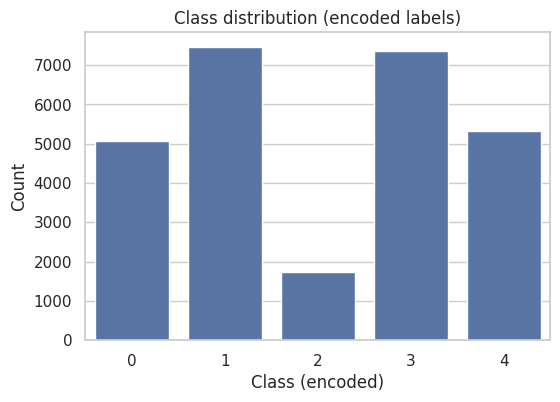


Class percentage:
                    count  percent
URL_Type_obf_Type                
0                   5068    18.80
1                   7464    27.69
2                   1731     6.42
3                   7359    27.30
4                   5331    19.78


In [ ]:
class_counts = phish_data['URL_Type_obf_Type'].value_counts().sort_index()

# plot
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution (encoded labels)")
plt.xlabel("Class (encoded)")
plt.ylabel("Count")
plt.show()

# Recommendation printout
total = class_counts.sum()
perc = (class_counts/total*100).round(2)
print("\nClass percentage:\n", pd.concat([class_counts, perc.rename("percent")], axis=1))

**Feature Distributions**

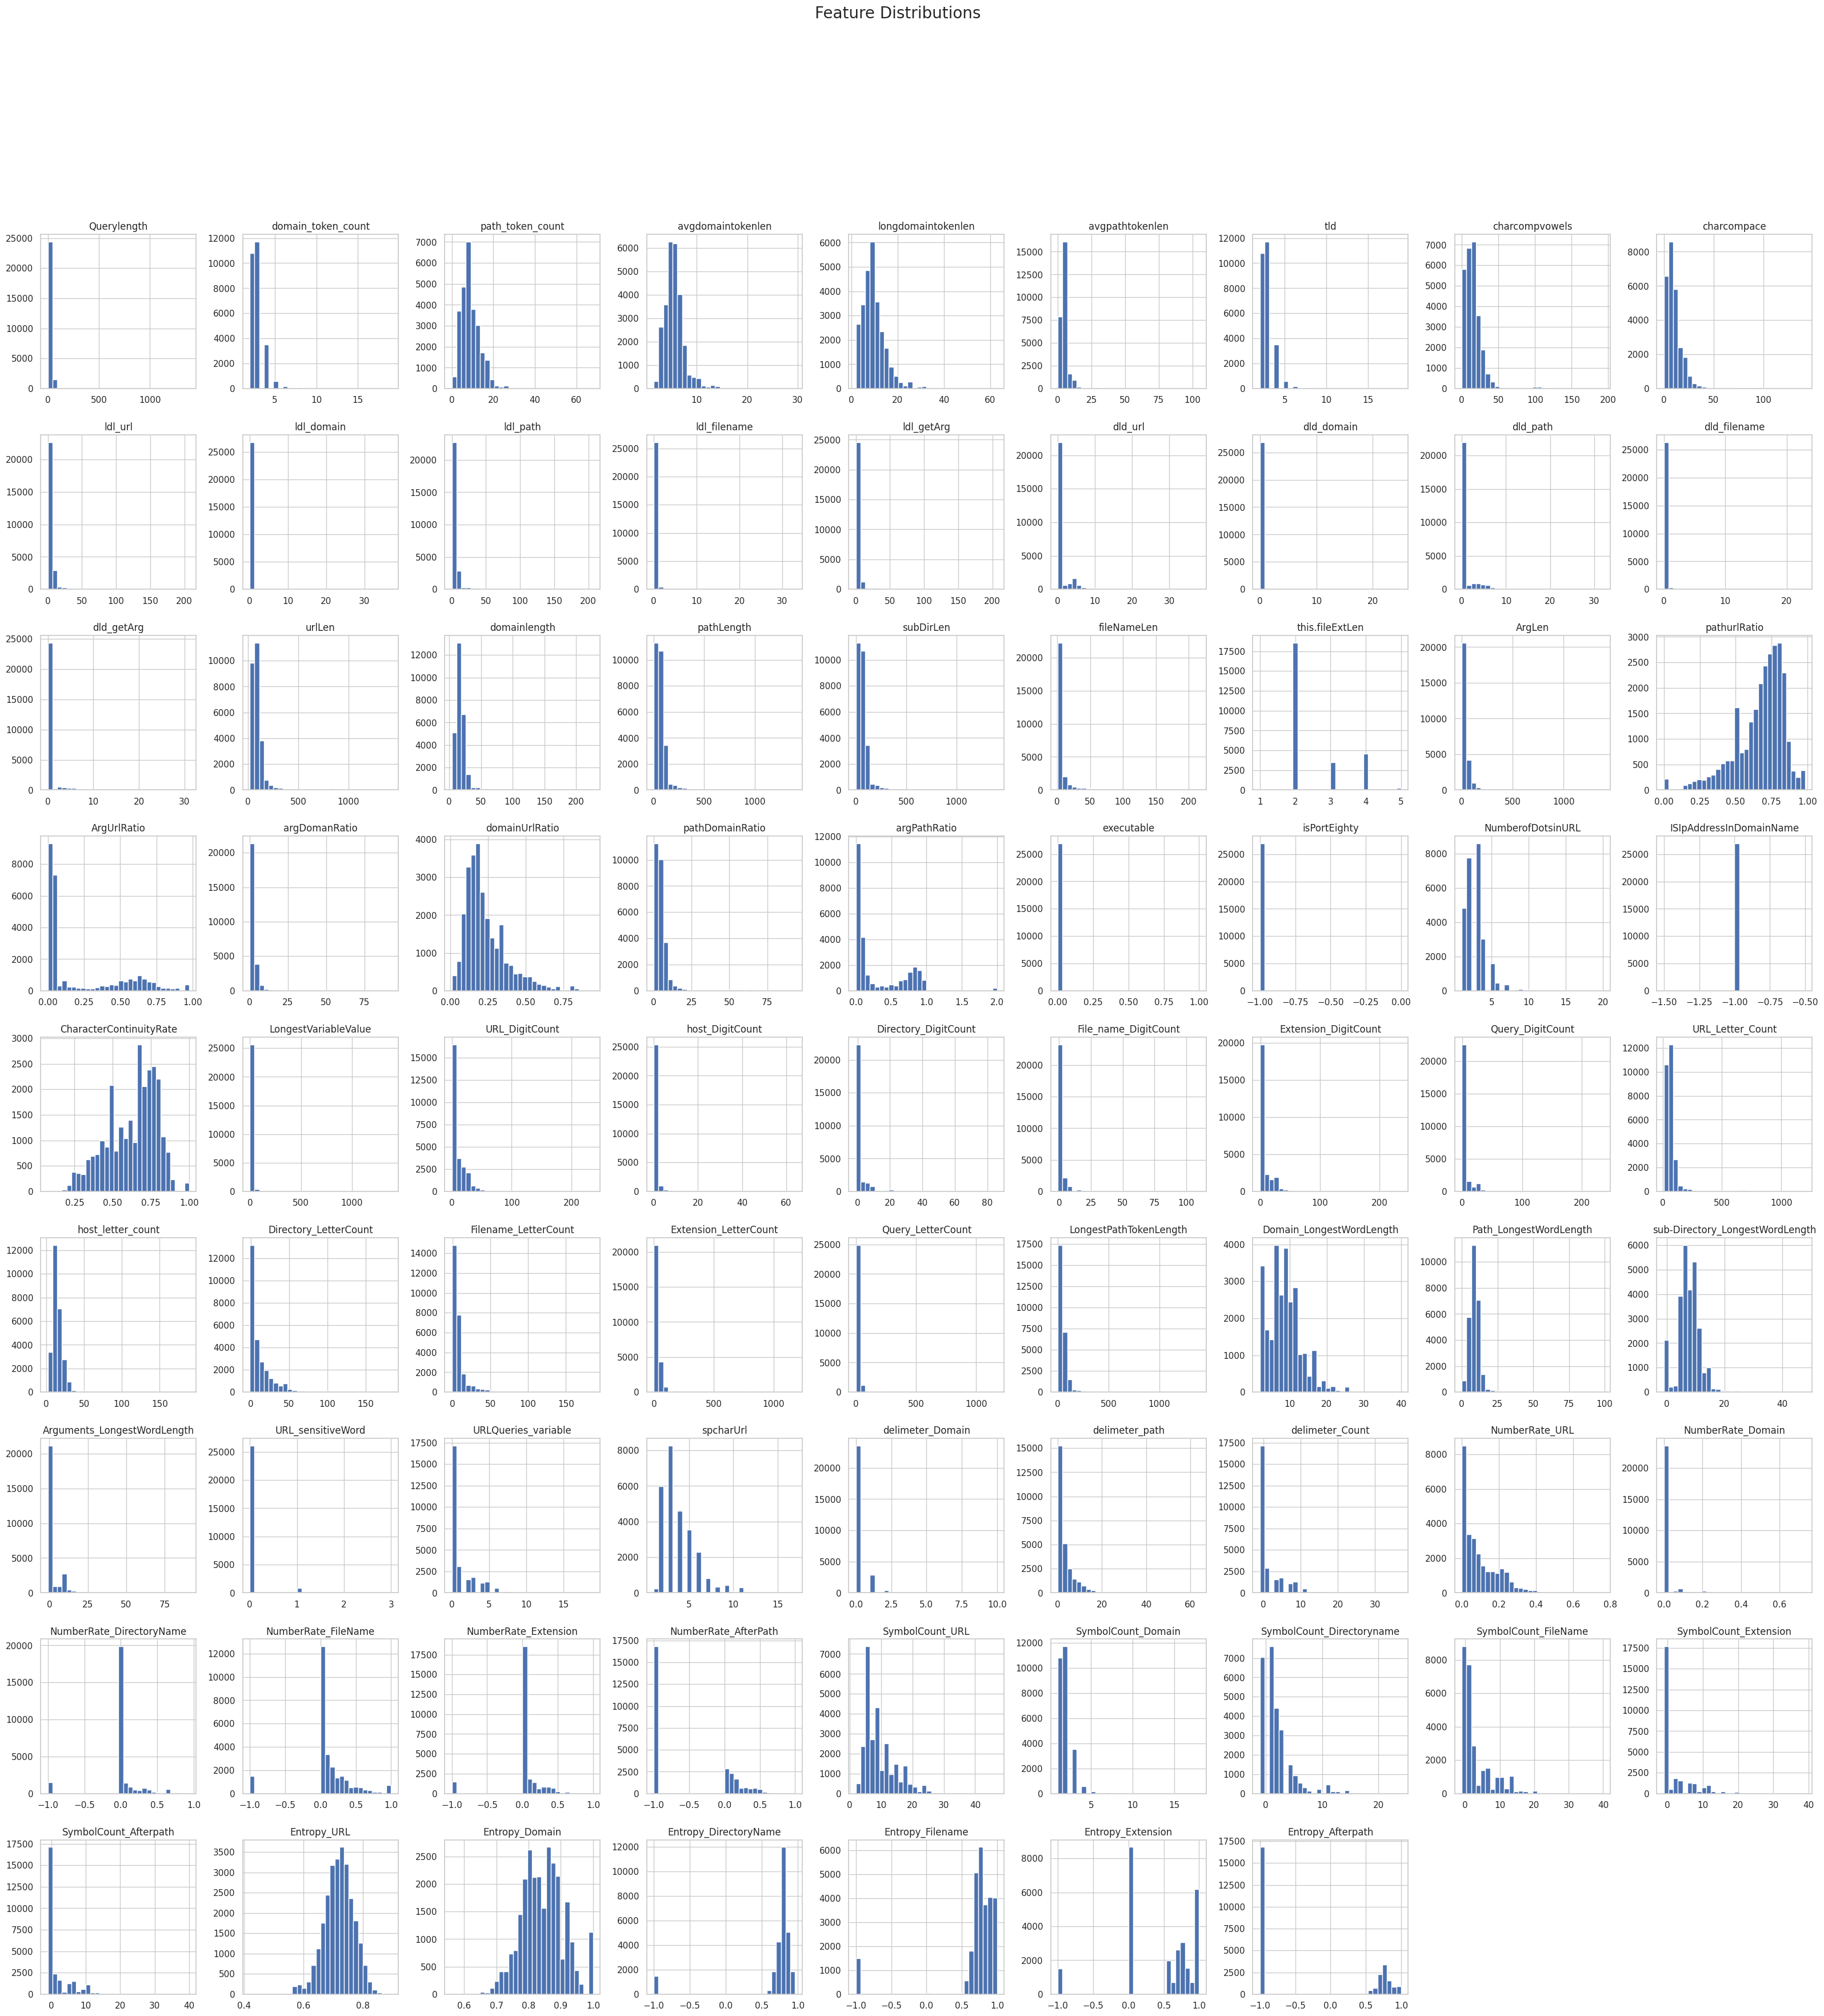

In [ ]:
phish_data[numeric_cols].hist(bins=30, figsize=(40,40))
plt.suptitle("Feature Distributions", fontsize=20)
plt.show()

**Skewness Analysis**

In [ ]:
skewness = phish_data[numeric_cols].skew().sort_values(ascending=False)
high_skew = skewness[skewness.abs() > 1]

print("Highly Skewed Features:\n", high_skew)

Highly Skewed Features:
 isPortEighty                58.021548
dld_domain                  57.175969
ldl_domain                  30.244220
executable                  22.924890
dld_filename                14.208434
                              ...    
pathurlRatio                -1.140475
NumberRate_DirectoryName    -1.831781
NumberRate_Extension        -2.037076
Entropy_Filename            -3.431380
Entropy_DirectoryName       -3.709321
Length: 70, dtype: float64


##**Detecting & Handling Outliers**

In [ ]:
count_features = [
    'Querylength', 'domain_token_count', 'path_token_count',
    'urlLen', 'domainlength', 'pathLength', 'subDirLen',
    'fileNameLen', 'ArgLen', 'NumberofDotsinURL',
    'URL_DigitCount', 'host_DigitCount',
    'Directory_DigitCount', 'File_name_DigitCount',
    'Extension_DigitCount', 'Query_DigitCount',
    'SymbolCount_URL', 'SymbolCount_Domain',
    'SymbolCount_Directoryname', 'SymbolCount_FileName',
    'SymbolCount_Extension', 'SymbolCount_Afterpath',
    'LongestPathTokenLength', 'Domain_LongestWordLength',
    'Path_LongestWordLength'
]

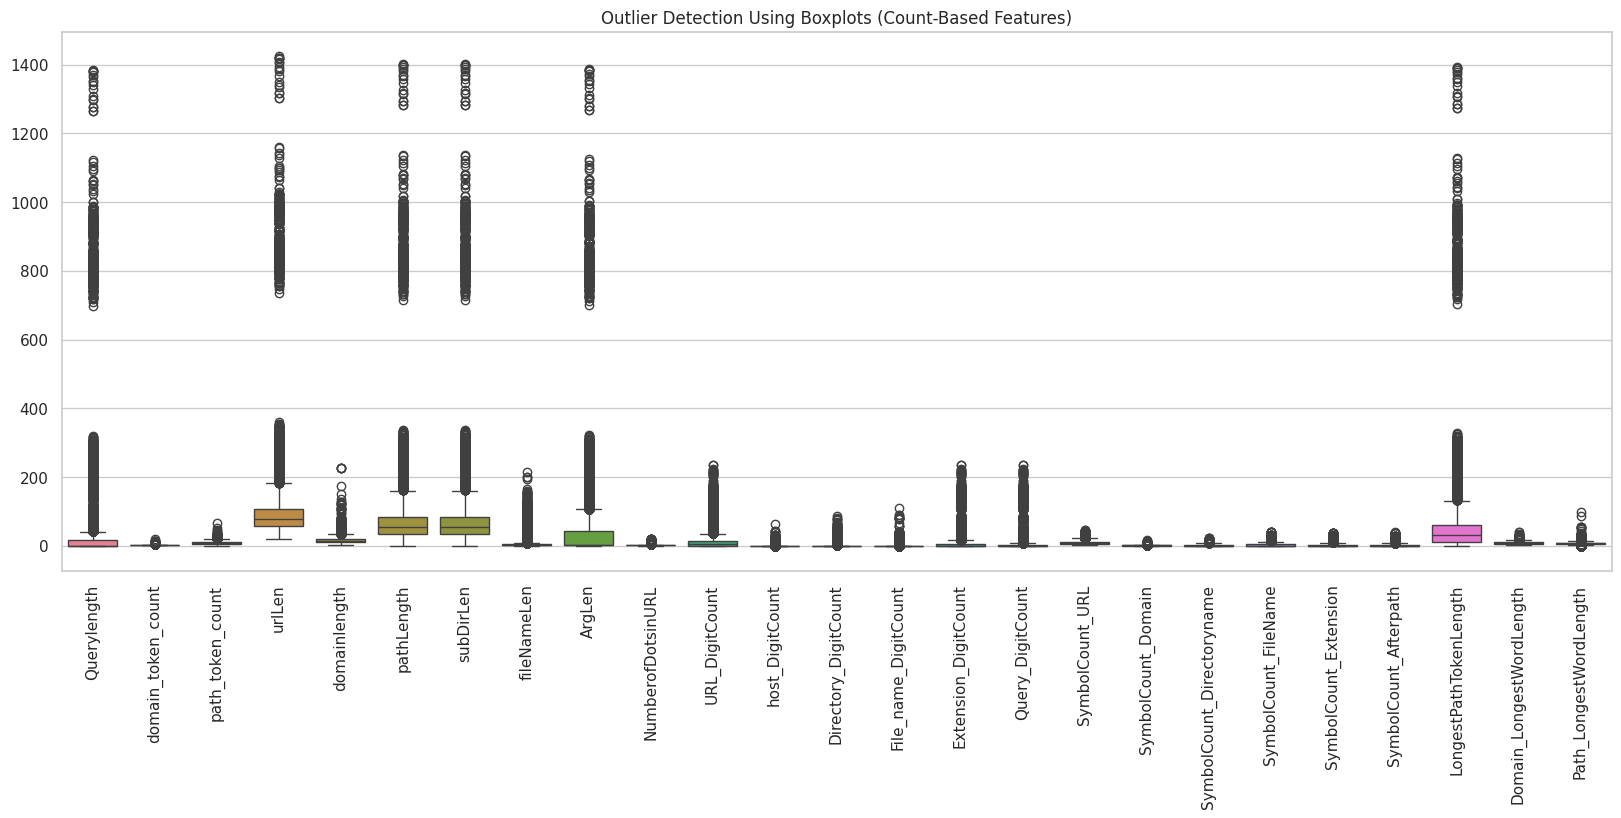

In [ ]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=phish_data[count_features])
plt.xticks(rotation=90)
plt.title("Outlier Detection Using Boxplots (Count-Based Features)")
plt.show()

In [ ]:
# List of features with obvious extreme outliers from boxplot
outlier_cols_to_cap = [
    'Querylength','urlLen','pathLength','subDirLen', 'ArgLen', 'LongestPathTokenLength'
]


# Ensure they exist in the dataset
outlier_cols_to_cap = [c for c in outlier_cols_to_cap if c in phish_data.columns]

# Function to cap outliers using IQR
def cap_outliers_iqr(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

# Apply capping
phish_data_capped = cap_outliers_iqr(phish_data, outlier_cols_to_cap)

# Verify: check min, max values after capping
phish_data_capped[outlier_cols_to_cap].describe()


,Querylength,urlLen,pathLength,subDirLen,ArgLen,LongestPathTokenLength
count,26953.000000,26953.000000,26953.000000,26953.000000,26953.000000,26953.000000
mean,9.605981,86.009869,62.087523,62.087523,23.664045,40.740289
std,15.519029,38.355820,38.516381,38.516381,34.481593,34.394287
min,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,57.000000,34.000000,34.000000,2.000000,12.000000
50%,0.000000,78.000000,54.000000,54.000000,2.000000,32.000000
75%,17.000000,107.000000,85.000000,85.000000,44.000000,60.000000
max,42.500000,182.000000,161.500000,161.500000,107.000000,132.000000


**Correlation**

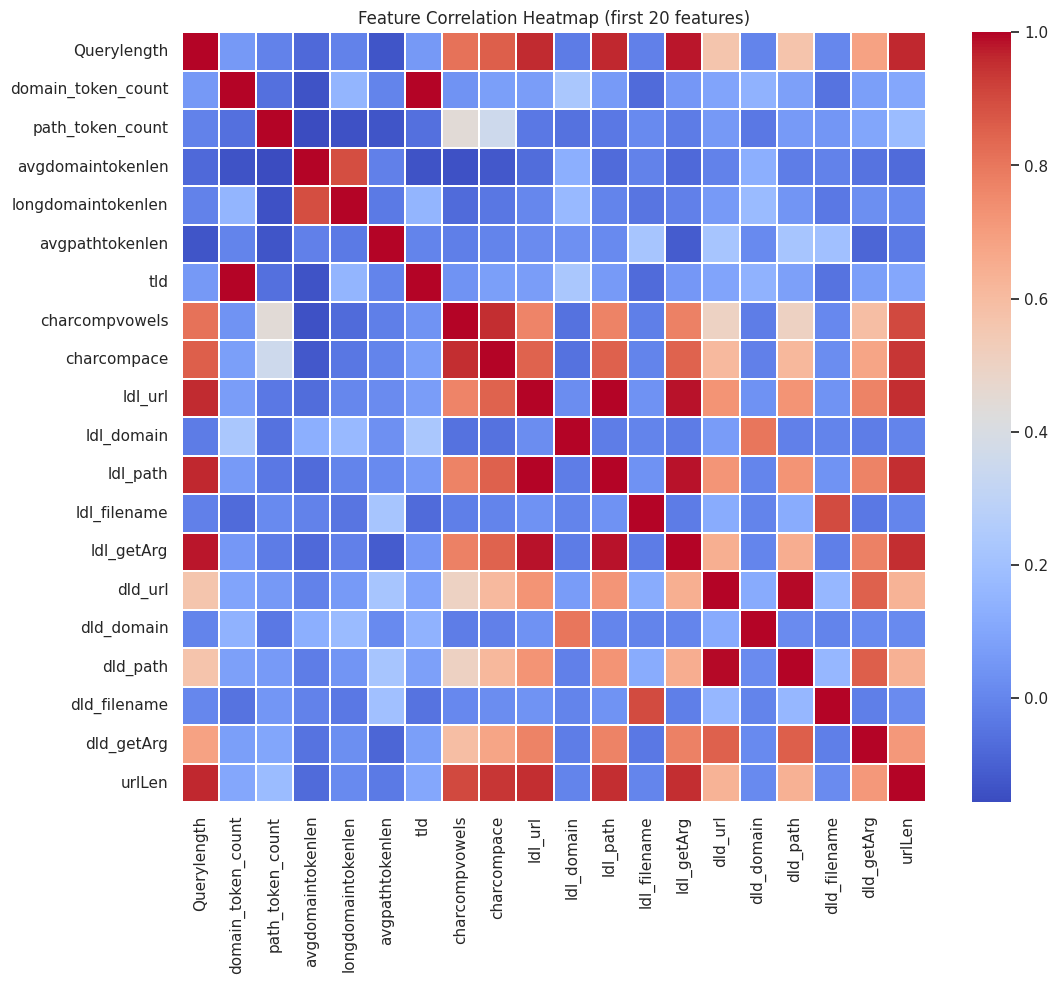

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(X.iloc[:, :20].corr(), cmap='coolwarm', linewidths=0.2)
plt.title("Feature Correlation Heatmap (first 20 features)")
plt.show()

 **Identifying highly correlated feature pairs (abs(corr) >= 0.9)**

In [ ]:
# Select only numeric columns
numeric_cols = phish_data.select_dtypes(include=[np.number]).columns

# Compute absolute correlation matrix
corr_matrix = phish_data[numeric_cols].corr().abs()

# Create upper triangle matrix (to avoid duplicate pairs)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify feature pairs with correlation >= 0.90
high_corr_pairs = upper_triangle.stack().loc[lambda x: x >= 0.90].sort_values(ascending=False)
print("Number of feature pairs with |corr| >= 0.90:", len(high_corr_pairs))
print(high_corr_pairs.head(30))  # Show top 30 highly correlated pairs

# Identify columns to drop to reduce multicollinearity
to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.90)]
print("Columns to drop due to high correlation:", to_drop)

# Drop the identified columns
phish_data.drop(columns=to_drop, inplace=True)


Number of feature pairs with |corr| >= 0.90: 153
domain_token_count     tld                       1.000000
pathLength             subDirLen                 1.000000
ldl_url                ldl_path                  0.999040
domain_token_count     SymbolCount_Domain        0.998155
tld                    SymbolCount_Domain        0.998155
Querylength            Query_LetterCount         0.997985
urlLen                 pathLength                0.997101
                       subDirLen                 0.997101
Querylength            LongestVariableValue      0.996796
LongestVariableValue   Query_LetterCount         0.995824
dld_url                dld_path                  0.995203
URLQueries_variable    delimeter_Count           0.993879
ArgLen                 argDomanRatio             0.993306
urlLen                 URL_Letter_Count          0.993196
pathLength             URL_Letter_Count          0.990535
subDirLen              URL_Letter_Count          0.990535
Extension_LetterCount  

In [ ]:
print("Shape:", phish_data.shape)
print("\nDataset Info:")
print(phish_data.info())

Shape: (26953, 52)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 26953 entries, 0 to 36706
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      26953 non-null  int64  
 1   domain_token_count               26953 non-null  int64  
 2   path_token_count                 26953 non-null  int64  
 3   avgdomaintokenlen                26953 non-null  float64
 4   longdomaintokenlen               26953 non-null  int64  
 5   avgpathtokenlen                  26953 non-null  float64
 6   charcompvowels                   26953 non-null  int64  
 7   ldl_domain                       26953 non-null  int64  
 8   ldl_filename                     26953 non-null  int64  
 9   dld_url                          26953 non-null  int64  
 10  dld_domain                       26953 non-null  int64  
 11  dld_filename                     26953 non-null  in

##Model Development

**Train/Test Split & Scaling**

In [ ]:


X = phish_data.drop("URL_Type_obf_Type", axis=1)
y = phish_data["URL_Type_obf_Type"]


X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

test_data = X_test.copy()
test_data["URL_Type_obf_Type"] = y_test.values
test_data.to_csv("test_dataset.csv", index=False)
print("Test dataset saved as test_dataset.csv")



X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Test dataset saved as test_dataset.csv


**Handle Imbalance (SMOTE)**

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


**RandomForest Hyperparameter Tuning**

In [ ]:
param_dist = {
    "n_estimators": randint(300, 600),
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True, False]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_train_res, y_train_res)

print("Best Parameters:", random_search.best_params_)
print("Best CV F1 Score:", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'bootstrap': False, 'max_depth': 40, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 579}
Best CV F1 Score: 0.9702950356737516



Validation Accuracy: 0.9682804674457429

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      1014
           1       0.98      0.99      0.98      1493
           2       0.97      0.89      0.93       346
           3       0.94      0.97      0.95      1472
           4       0.99      0.97      0.98      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.96      0.96      5391
weighted avg       0.97      0.97      0.97      5391



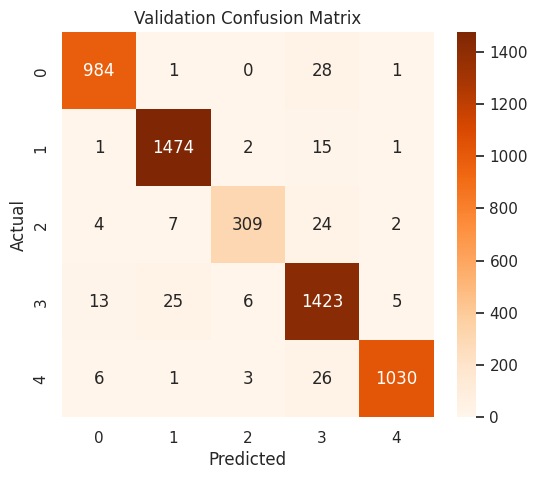

Validation ROC AUC Score: 0.9976206825961276


In [ ]:
rf_best = random_search.best_estimator_

y_val_pred = rf_best.predict(X_val_scaled)
y_val_proba = rf_best.predict_proba(X_val_scaled)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nValidation Classification Report:\n", classification_report(y_val, y_val_pred))

val_cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(val_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

val_roc_auc = roc_auc_score(y_val, y_val_proba, multi_class="ovr")
print("Validation ROC AUC Score:", val_roc_auc)

**Train Final Model**

In [ ]:
# 8. Merge TRAIN + VALIDATION for final model
# ---------------------------
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.hstack([y_train, y_val])

X_trainval_res, y_trainval_res = sm.fit_resample(X_trainval_scaled, y_trainval)

rf_tuned = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_trainval_res, y_trainval_res)

RandomForestClassifier(bootstrap=False, max_depth=40, min_samples_leaf=2,
                       min_samples_split=6, n_estimators=579, n_jobs=-1,
                       random_state=42)

#Final Evaluation


Test Accuracy: 0.9701354108699685

Test Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1014
           1       0.98      0.98      0.98      1493
           2       0.97      0.87      0.92       346
           3       0.94      0.97      0.96      1472
           4       1.00      0.98      0.99      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.96      0.96      5391
weighted avg       0.97      0.97      0.97      5391



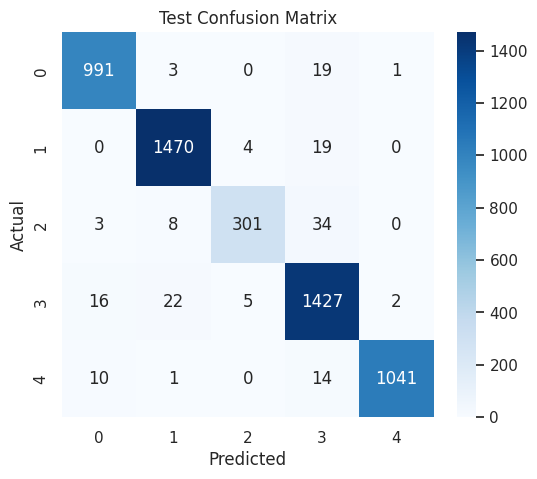

Test ROC AUC Score: 0.997825818939593


In [ ]:

y_test_pred = rf_tuned.predict(X_test_scaled)
y_test_proba = rf_tuned.predict_proba(X_test_scaled)

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred))

test_cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

test_roc_auc = roc_auc_score(y_test, y_test_proba, multi_class="ovr")
print("Test ROC AUC Score:", test_roc_auc)

#Save Files for VS Code Frontend

In [ ]:
joblib.dump(rf_tuned, "rf_tuned_model.pkl")
joblib.dump(scaler, "scaler.pkl")

with open("feature_order.txt", "w") as f:
    for col in X.columns:
        f.write(col + "\n")

print("Saved:")
print("- rf_tuned_model.pkl")
print("- scaler.pkl")
print("- feature_order.txt")
print("- test_dataset.csv")


Saved:
- rf_tuned_model.pkl
- scaler.pkl
- feature_order.txt
- test_dataset.csv


In [ ]:
from google.colab import files
# Download the trained RandomForest model
files.download("rf_tuned_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download the scaler
files.download("scaler.pkl")

# Download the feature order
files.download("feature_order.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>